In [37]:
import sys  
!{sys.executable} -m pip install --user matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import numpy as np
import random
from copy import deepcopy
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Constants
UP = 0
DOWN = 1
LEFT = 2
RIGHT = 3

## Simulating a move
Simulates a move (UP,DOWN,LEFT OR RIGHT) on the np array.
This function when invoked uses if-else to branch into
four operations which are completed using the slide and
merge helper function
### Implemenation :
For each function call, a new 4x4 np array initialized
with 0 is formed. This iterrates over range 4 to add rows 
or columns returned by the slide_and_mergee function

## Merging
This acts as a helper function to be called by _simulate_move()_.
### Implementation :
The zeroes are removed as they are just empty spaces and not
needed for the merging process. Zeroes will be added back
at the end.

In [39]:
def slide_and_merge(line):
    line = line[line != 0] 
    merged = []
    # The skip variable is used to skip the value in the array 
    # that has already been merged
    skip = False
    
    for i in range(len(line)):
        if skip:
            skip = False
            continue
        # We check if the element at the next index is equal and
        # therfore has to be merged
        if i + 1 < len(line) and line[i] == line[i + 1]:
            merged.append(line[i] * 2)
            # Now the element at [i+1] is skipped
            skip = True
        # Otherwise we just copy the elements
        else:
            merged.append(line[i])
    
    # 'merged' is converteed to np.array to use pad function
    merged = np.array(merged)
    # np.pad() pads the line with 0s for length '4-length of line'
    merged = np.pad(merged, (0, 4 - len(merged)), 'constant')
    return merged

In [40]:
def simulate_move(board, direction):
    new_board = np.zeros_like(board)
    
    if direction == LEFT:
        for i in range(4):
            row = board[i, :]
            new_row = slide_and_merge(row)
            new_board[i, :] = new_row
    elif direction == RIGHT:
        for i in range(4):
            # array is rversed so the slide action changes direction
            row = board[i, ::-1]
            new_row = slide_and_merge(row)
            new_board[i, ::-1] = new_row
    elif direction == UP:
        for j in range(4):
            col = board[:, j]
            new_col = slide_and_merge(col)
            new_board[:, j] = new_col
    elif direction == DOWN:
        for j in range(4):
            # array is rversed so the slide action changes direction
            col = board[::-1, j]
            new_col = slide_and_merge(col)
            new_board[::-1, j] = new_col
    
    return new_board

### Getting search depth :
This function enables the code to do deeper searches once a high enough tile has appeared on the board

In [41]:
def get_search_depth(board):
    max_tile = np.max(board)
    if max_tile >= 1024:
        return 4  # Deeper search
    else:
        return 3

# HEURISTICS
>**The algorithm uses `Heuristics` to determine the favorability of
the current board towards winning the game. This approach assigns a
number based on cerain properties of the game to each board conditon.
The higher the number, better is the condition of the board towards 
winning. There are** _four_ **properties used in this algo:**
   1. ### Empty :
             number of empty cells currently on the board. Less empty cells means options can quickly run out when the board gets cramped.
   2. ### Monotonicity :
             this checks whther the tiles are in ascending or descending order across row and column as this is optimal for merging.
   3. ### Smoothness:
             calculates sum of logarithnic differences between adjacent tiles, as values need to be equal for them to merge.
   4. ### Corner :
             A technique used by players tomanage numbers on the board better, is to place the highest number on any of the four corners so that it doesn't get mixed up on the board.
   5. ### Gradient :
             encourages the board to form snake like pattern which is optimal for merging in later stages.
   6. ### Potential merges :
             counts the total merges available on the current board. Generally, the higher the better.

In [42]:
# Returns currently empty cells on the board. the higher the better
def count_empty_cells(board):
    return np.count_nonzero(board == 0)

In [43]:
# Returns the number of adjacent pairs that are in non-increasing order
def monotonicity(board):
    mono = 0
    for i in range(4):
        for j in range(3):
            if board[i, j] >= board[i, j + 1]:
                mono += 1
            if board[j, i] >= board[j + 1, i]:
                mono += 1
    return mono

In [44]:
# Returns negative of logarithmic difference of adjacent pairs
def smoothness(board):
    smooth = 0
    for i in range(4):
        for j in range(4):
            if board[i, j] != 0:
                val = np.log2(board[i, j])
                for (di, dj) in [(0, 1), (1, 0)]:
                    ni, nj = i + di, j + dj
                    if ni < 4 and nj < 4 and board[ni, nj] != 0:
                        smooth -= abs(val - np.log2(board[ni, nj]))
    return smooth

In [45]:
# Returns a boolean whether the highest value is in the corner or not
def max_tile_in_corner(board):
    max_tile = np.max(board)
    return 1 if (board[0, 0] == max_tile or 
                board[0, 3] == max_tile or 
                board[3, 0] == max_tile or 
                board[3, 3] == max_tile) else 0

In [46]:
# Returns reward if snake pattern
def gradient_heuristic(board):
    weights = np.array([
        [15, 14, 13, 12],
        [8, 9, 10, 11],
        [7, 6, 5, 4],
        [0, 1, 2, 3]
    ])
    return np.sum(board * weights)

In [47]:
# Returns number of merges available on currennt board
def potential_merges(board):
    merges = 0
    for i in range(4):
        for j in range(3):
            if board[i, j] == board[i, j + 1] and board[i, j] != 0:
                merges += 1
            if board[j, i] == board[j + 1, i] and board[j, i] != 0:
                merges += 1
    return merges

### Implementation of _Heuristics_ :
   > <span style="color: purple;">The heuristics or the intelligence of the algorithm.
   This returns a number indicating favourability of the
   board by adding all 4 properties multiplied by an
   'importance factor' or a weight determined by how
    important that factor is at any stage, for winning.</span>

In [48]:
def heuristic(board):
    empty = count_empty_cells(board)
    mono = monotonicity(board)
    smooth = smoothness(board)
    corner = max_tile_in_corner(board)
    merges = potential_merges(board)
    gradient = gradient_heuristic(board)

    return (12 * empty + 
            15 * mono + 
            5 * smooth + 
            150 * corner + 
            20 * merges +
            10 * gradient)

# EXPECTIMAX
### Description :
>This is the brawn of the code. Expectimax algorithm is a
variation of Minimax. While minimax assumes the adversary 
(in this case the random tile generrator) plays optimally, (or
in this case gives the worst tile genration according to the 
situation) Expectimax doesn't. It requires the entire tree or
all the possibilites of tile generation to be explored.
## `Graph of Minimax tree` :
![MINIMAX](https://media.geeksforgeeks.org/wp-content/uploads/20200109213207/minimaxdrawing.jpg)
#### <span style="color: #1D7557;"> Being the  </span>**MAXIMIZER**,  <span style="color: #1D7557;">  you would go left given thaat the </SPAN> **MINIMIZER** <span style="color: #1D7557;"> plays optimally. But what if there is a probability of the minimizer making a mistake ?
#### <span style="color: #1D7557;">Perchance the </span>**MINIMIZER** <span style="color: #1D7557;">does not play optimally, choosing right could give _100_, opposed to the left one giving _10_.</span>
## `Graph of Expectimax tree` :
![EXPECTIMAX](https://media.geeksforgeeks.org/wp-content/uploads/20200109213236/expectimaxdrawing.jpg)
#### <span style="color: #1D7557;">In the above graph, we replaced</span> **MINIMIZER** <span style="color: #1D7557;">nodes with chance nodes. These take average of all branches with their probability. In this case, </SPAN> **(10+10)/2=10 & (9+100)/2=54.5,** <span style="color: #1D7557;">thus </SPAN>**EXPECTIMAX** <span style="color: #1D7557;">choses right.
><span style="color: red;">**Note that in case of optimal play, this does return with a lower value compared to** `MINIMAX`

## The recursive expectimax algoritm used here works as shown:
   1. ### First recursive call :
     After a move has been made, the new board is passed to
        the algorithm with depth '3'. As 'is_maxixmizing" is false,
        at the first call, it branches into all tile possbilities
        at all the empty positoins, with a probability factor (0.9 for 2).
        
   2. ### Second recursive call :
     Depth is now '2' and 'is_maximizing' is true. For each branch,
        four branches are formed with the second recursive call. Each
        corresponding to a sliding operation.
        
   3. ### Third recursive call :
     For each slidig operation, the third reecursive call and all 
        tile possibilities are mapped
        
   4. ### Fourth recursive call :
     At the fourth recursive call the heuristics of the board after
        these operations are calculated for each sub-brach. Thus all 
        the branches converge with multiplied probability and return
        a number based on how favourable would the board be after that
        operation at a search depth of '3'.

In [49]:
expectimax_calls = 0

def expectimax(board, depth, is_maximizing):
    global expectimax_calls
    expectimax_calls += 1
    if depth == 0 or game_over(board):
        return heuristic(board)
    
    if is_maximizing:
        max_eval = -np.inf
        for move in [UP, DOWN, LEFT, RIGHT]:
            new_board = simulate_move(board, move)
            if not np.array_equal(board, new_board):  # Valid move
                eval = expectimax(new_board, depth - 1, False)
                max_eval = max(max_eval, eval)
        return max_eval
    else:
        empty_positions = list(zip(*np.where(board == 0)))
        total_eval = 0
        for pos in empty_positions:
            for tile in [2, 4]:
                new_board = deepcopy(board)
                new_board[pos] = tile
                prob = 0.9 if tile == 2 else 0.1
                total_eval += prob * expectimax(new_board, depth - 1, True)
        return total_eval / len(empty_positions) if empty_positions else 0

### Best move :
<span style="color: #3A509B;">**Iterates through all possible moves and passes the new board to Expectimax, which then return a number baseed on favourablty. Thus the best move is chosen taking the max of these numbers.**</span>

In [50]:
def get_best_move(board):
    global expectimax_calls
    expectimax_calls = 0 
    
    best_move = None
    best_eval = -np.inf
    for move in [UP, DOWN, LEFT, RIGHT]:
        new_board = simulate_move(board, move)
        if not np.array_equal(board, new_board):  # Valid move
            eval = expectimax(new_board, depth=3, is_maximizing=False)
            if eval > best_eval:
                best_eval = eval
                best_move = move
    return best_move if best_move is not None else random.choice([UP, DOWN, LEFT, RIGHT]),expectimax_calls

### Tile generation :
<span style="color: #3A509B;">**Adds a tile (2 with 0.9 probaility) on a random free cell out of the free cells available**</span>

In [51]:
def add_random_tile(board):
    """Adds a random tile (2 or 4) to an empty cell."""
    empty_positions = list(zip(*np.where(board == 0)))
    if empty_positions:
        pos = random.choice(empty_positions)
        board[pos] = 2 if random.random() < 0.9 else 4

### Exit condition :
<span style="color: #3A509B;">**returns boolean based on whether the game is over by checking if the number of valid moves left is 0.**</span> 

In [52]:
def game_over(board):
    for move in [UP, DOWN, LEFT, RIGHT]:
        new_board = simulate_move(board, move)
        if not np.array_equal(board, new_board):
            return False
    return True

## Game Board :
<span style="color: #0DAF97;">**The methond that binds it all together. The while loop keeps
calling the best mmove function till its game over or 2048 is
reached. the finishing board is displayed.**</span>

In [53]:
def play_2048():
    """Main game loop."""
    board = np.zeros((4, 4), dtype=int)
    add_random_tile(board)
    add_random_tile(board)
    
    moves = 0
    heuristic_values=[]
    call_counts = []
    
    plt.figure(figsize=(24, 20))
    
    while not game_over(board):
        move,calls = get_best_move(board)
        board = simulate_move(board, move)
        add_random_tile(board)
        moves += 1

        # Calculate and store heuristic value
        h_val = heuristic(board)
        heuristic_values.append(h_val)
        call_counts.append(calls)

        clear_output(wait=True)
        plt.clf()

        # Plotting
        plt.subplot(1, 2, 1)
        plt.plot(range(1, moves+1), heuristic_values, 'b-')
        plt.title('Heuristic Value vs Moves')
        plt.xlabel('Move Number')
        plt.ylabel('Heuristic Value')
        plt.grid(True)

        # Call count subplot
        plt.subplot(1, 2, 2)
        plt.plot(range(1, moves+1), call_counts, 'r-')
        plt.title('Expectimax Calls vs Moves')
        plt.xlabel('Move Number')
        plt.ylabel('Number of Calls')
        plt.grid(True)

        plt.tight_layout()
        plt.show()
        
        # print(f"Move {moves}:")
        # print(board)
        if np.max(board) >= 2048:
            print(f"🎉 2048 achieved in {moves} moves!")
            break
    print(f"Game over. number of moves: {moves} ")
    print(board)

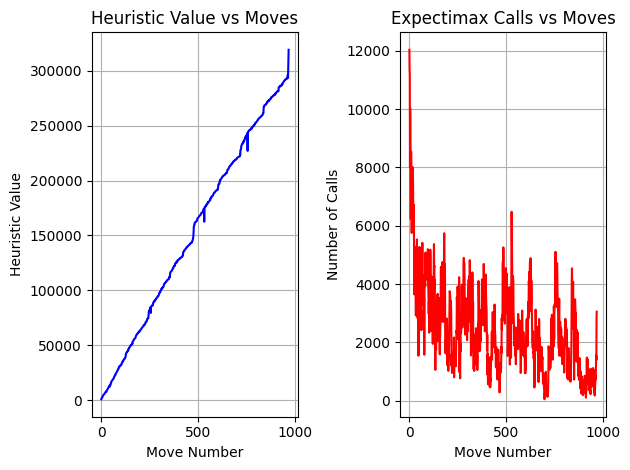

🎉 2048 achieved in 969 moves!
Game over. number of moves: 969 
[[2048   64    0    0]
 [   4    8    4    0]
 [   8    2    4    0]
 [   8    2    0    0]]


In [54]:
# Run the game
play_2048()

><span style="color: red;">The output has two plots